In [9]:
!pip install missingno

   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   - -------------------------------------- 1.0/36.6 MB 7.2 MB/s eta 0:00:05
   ----- ---------------------------------- 4.7/36.6 MB 15.0 MB/s eta 0:00:03
   -------- ------------------------------- 7.9/36.6 MB 14.3 MB/s eta 0:00:03
   ----------- ---------------------------- 10.5/36.6 MB 13.9 MB/s eta 0:00:02
   -------------- ------------------------- 13.6/36.6 MB 13.6 MB/s eta 0:00:02
   ------------------ --------------------- 16.8/36.6 MB 13.7 MB/s eta 0:00:02
   ----------------------- ---------------- 21.5/36.6 MB 14.9 MB/s eta 0:00:02
   ----------------------------- ---------- 26.7/36.6 MB 16.3 MB/s eta 0:00:01
   -------------------------------- ------- 29.9/36.6 MB 16.1 MB/s eta 0:00:01
   ------------------------------------ --- 33.0/36.6 MB 16.5 MB/s eta 0:00:01
   ---------------------------------------  35.9/36.6 MB 15.6 MB/s eta 0:00:01
   ---------------------------------------  36.4/36.6 MB 15.7 MB/

In [18]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.3 MB 32.8 MB/s eta 0:00:01
   ----------------- ---------------------- 3.7/8.3 MB 19.8 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.3 MB 14.1 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.3 MB 13.2 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.3 MB 13.2 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.3 MB 13.2 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 6.8 MB/s  0:00:01

   ---------------------------------------- 0/4 [threadpoolctl]
   ---------------------------------------- 0/4 [threadpoolctl]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- -------

In [26]:
!pip install ucimlrepo

# Задание 1. Обнаружение и обработка пропущенных значений

**Датасет:** titanic (пассажиры Титаника)  
**Источник:** `seaborn.load_dataset("titanic")`

## Инструкции:

1. Загрузите датасет titanic.

2. Определите количество пропущенных значений в каждом столбце.

3. Визуализируйте пропуски с помощью библиотеки **missingno**.

4. Заполните пропущенные значения:
   - признак **age** – средним значением;
   - признак **embarked** – наиболее частым значением;
   - признак **deck** – удалите.

5. Отобразите информацию о таблице до и после обработки (`.info()`, `.isna()`, `.sum()`).


 ДО ОБРАБОТКИ 
Размер датасета: 891 строк, 12 столбцов

 Количество пропущенных значений в каждом столбце:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

 ВИЗУАЛИЗАЦИЯ ПРОПУСКОВ 


<Figure size 1000x400 with 0 Axes>

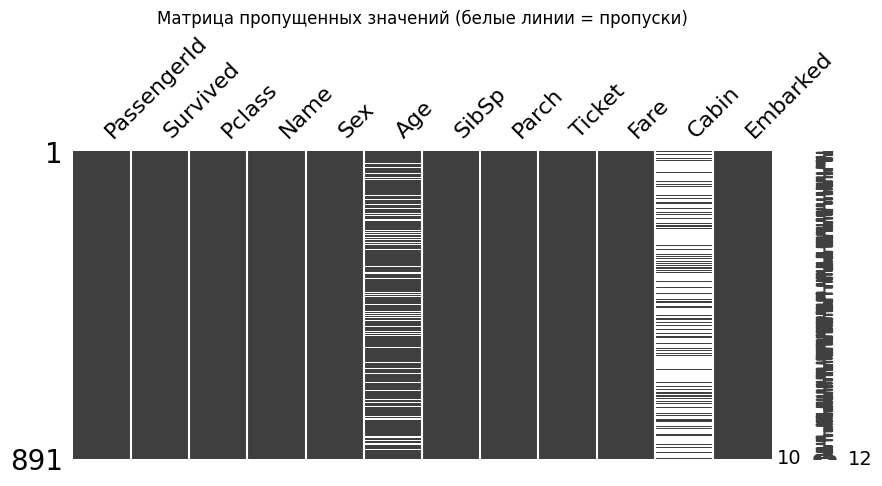


 ОБРАБОТКА ПРОПУСКОВ 
Средний возраст пассажиров: 29.7 лет
Наиболее частый порт посадки: 'S'
Удаляем столбец 'Cabin' (информация о каюте)

 ИНФОРМАЦИЯ О ТАБЛИЦЕ ДО ОБРАБОТКИ 
Метод .info():
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB
None

 Метод .isna().sum() ДО обработки:
PassengerId      0
Survived         0
Pclass           0
Name        

In [12]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt

# 1. Загрузите датасет titanic
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# 2. Определите количество пропущенных значений в каждом столбце
print("\n ДО ОБРАБОТКИ ")
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print("\n Количество пропущенных значений в каждом столбце:")
print(df.isna().sum())

# 3. Визуализируйте пропуски с помощью библиотеки missingno
print("\n ВИЗУАЛИЗАЦИЯ ПРОПУСКОВ ")

# Матрица пропусков
plt.figure(figsize=(10, 4))
msno.matrix(df, figsize=(10, 4))
plt.title('Матрица пропущенных значений (белые линии = пропуски)')
plt.show()

# 4. Заполните пропущенные значения
print("\n ОБРАБОТКА ПРОПУСКОВ ")

# Признак age - средним значением
age_mean = df['Age'].mean()
print(f"Средний возраст пассажиров: {age_mean:.1f} лет")
df['Age'] = df['Age'].fillna(age_mean)

# Признак embarked - наиболее частым значением
embarked_mode = df['Embarked'].mode()[0]
print(f"Наиболее частый порт посадки: '{embarked_mode}'")
df['Embarked'] = df['Embarked'].fillna(embarked_mode)

# Признак deck (Cabin) - удалите 
print("Удаляем столбец 'Cabin' (информация о каюте)")
df = df.drop(columns=['Cabin'])

# 5. Отобразите информацию о таблице до и после обработки
print("\n ИНФОРМАЦИЯ О ТАБЛИЦЕ ДО ОБРАБОТКИ ")
print("Метод .info():")
print(df.info())

print("\n Метод .isna().sum() ДО обработки:")
df_original = pd.read_csv(url)
print(df_original.isna().sum())

print("\n ИНФОРМАЦИЯ О ТАБЛИЦЕ ПОСЛЕ ОБРАБОТКИ ")
print("Метод .info():")
print(df.info())

print("\nМетод .isna().sum() ПОСЛЕ обработки:")
print(df.isna().sum())

# Итоговая проверка
print("\n ИТОГ ")
if df.isna().sum().sum() == 0:
    print("Все пропуски успешно обработаны!")
else:
    print(f"Осталось пропусков: {df.isna().sum().sum()}")

# Задание 2. Обнаружение и удаление выбросов

**Датасет:** penguins (описание антарктических пингвинов)  
**Источник:** `seaborn.load_dataset("penguins")`

## Инструкции:

1. Загрузите датасет penguins.

2. Постройте boxplot-графики для признаков `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`.

3. Используя метод межквартильного размаха (IQR), выявите и удалите выбросы по каждому из указанных признаков.

4. Сравните размеры датасета до и после фильтрации.

5. Постройте boxplot-график до и после удаления выбросов для одного из признаков.

 ДАТАСЕТ PENGUINS 
Размер датасета: 344 строк, 7 столбцов

 Первые 5 строк:
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  

 BOXPLOT-ГРАФИКИ ДО УДАЛЕНИЯ ВЫБРОСОВ 


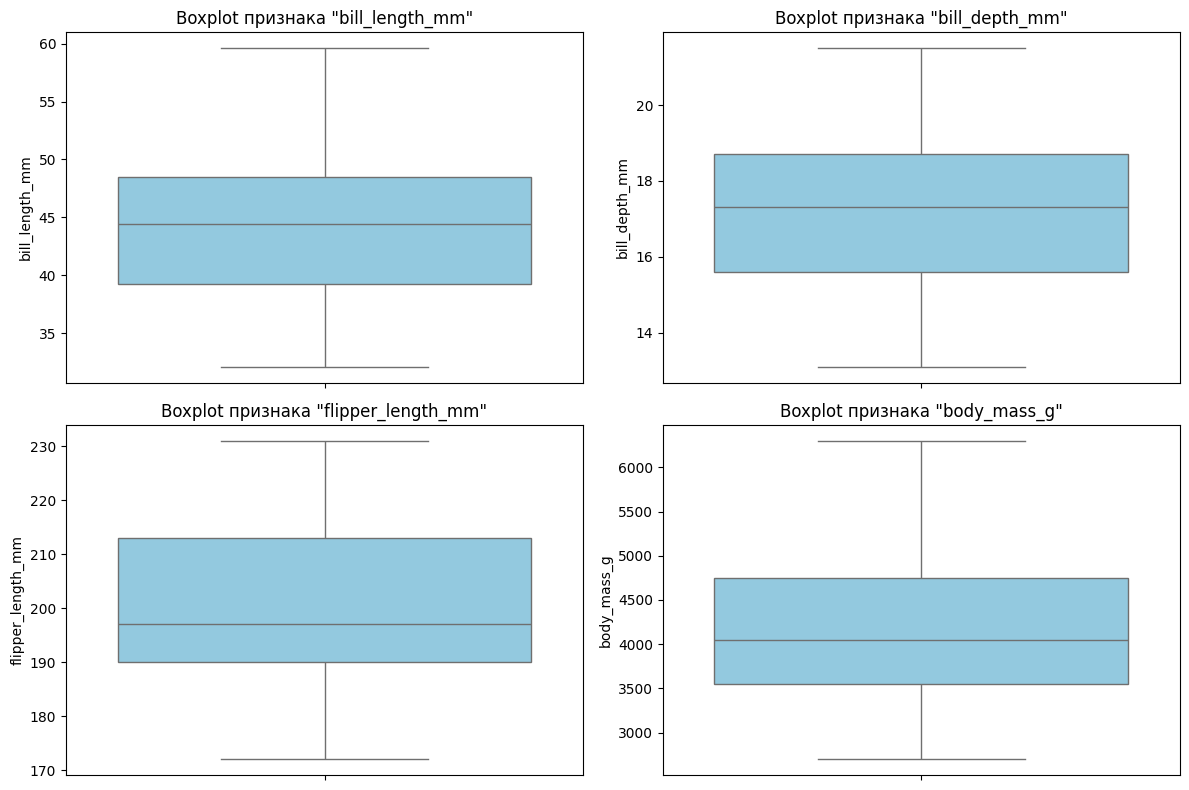


 УДАЛЕНИЕ ВЫБРОСОВ МЕТОДОМ IQR 

 Признак 'bill_length_mm':
  Q1 = 39.23, Q3 = 48.50, IQR = 9.27
  Нижняя граница: 25.31
  Верхняя граница: 62.41
  Количество выбросов: 0

 Признак 'bill_depth_mm':
  Q1 = 15.60, Q3 = 18.70, IQR = 3.10
  Нижняя граница: 10.95
  Верхняя граница: 23.35
  Количество выбросов: 0

 Признак 'flipper_length_mm':
  Q1 = 190.00, Q3 = 213.00, IQR = 23.00
  Нижняя граница: 155.50
  Верхняя граница: 247.50
  Количество выбросов: 0

 Признак 'body_mass_g':
  Q1 = 3550.00, Q3 = 4750.00, IQR = 1200.00
  Нижняя граница: 1750.00
  Верхняя граница: 6550.00
  Количество выбросов: 0

 СРАВНЕНИЕ РАЗМЕРОВ ДАТАСЕТА 
Размер до удаления выбросов: 344 строк
Размер после удаления выбросов: 342 строк
Удалено строк: 2
Удалено процентов: 0.58%

 СРАВНЕНИЕ BOXPLOT-ГРАФИКОВ ДО И ПОСЛЕ 


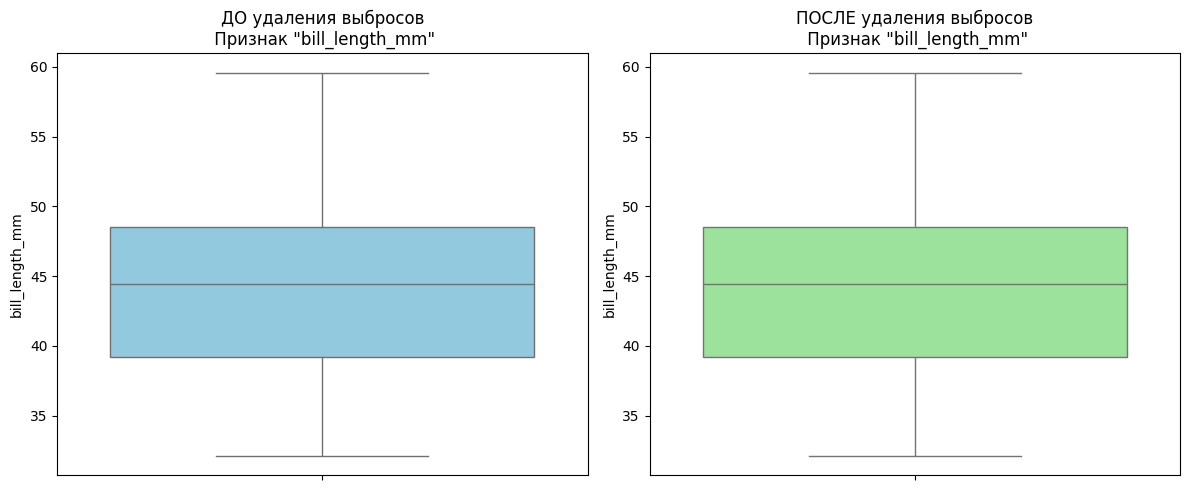


=== ИТОГ ===
 Выбросы успешно удалены методом IQR!
   Исходный датасет: 344 строк
   Очищенный датасет: 342 строк


In [15]:
import seaborn as sns

# 1. Загрузка датасета penguins
df = sns.load_dataset("penguins")

print(" ДАТАСЕТ PENGUINS ")
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print("\n Первые 5 строк:")
print(df.head())

# 2. Построение boxplot-графиков для указанных признаков
print("\n BOXPLOT-ГРАФИКИ ДО УДАЛЕНИЯ ВЫБРОСОВ ")

features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

plt.figure(figsize=(12, 8))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[feature], color='skyblue')
    plt.title(f'Boxplot признака "{feature}"')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

# 3. Удаление выбросов методом IQR
print("\n УДАЛЕНИЕ ВЫБРОСОВ МЕТОДОМ IQR ")

# Сохраняем копию исходного датасета
df_original = df.copy()

# Функция для поиска выбросов по IQR
def find_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1                      
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    print(f"\n Признак '{column}':")
    print(f"  Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}")
    print(f"  Нижняя граница: {lower_bound:.2f}")
    print(f"  Верхняя граница: {upper_bound:.2f}")
    print(f"  Количество выбросов: {len(outliers)}")
    
    return lower_bound, upper_bound

# Удаляем выбросы из датасета
df_clean = df.copy()

for feature in features:
    lower, upper = find_outliers_iqr(df_clean, feature)
    df_clean = df_clean[(df_clean[feature] >= lower) & (df_clean[feature] <= upper)]

# 4. Сравнение размеров датасета до и после фильтрации
print("\n СРАВНЕНИЕ РАЗМЕРОВ ДАТАСЕТА ")
print(f"Размер до удаления выбросов: {len(df_original)} строк")
print(f"Размер после удаления выбросов: {len(df_clean)} строк")
print(f"Удалено строк: {len(df_original) - len(df_clean)}")
print(f"Удалено процентов: {(len(df_original) - len(df_clean)) / len(df_original) * 100:.2f}%")

# 5. Построение boxplot-графика до и после удаления выбросов для одного признака
print("\n СРАВНЕНИЕ BOXPLOT-ГРАФИКОВ ДО И ПОСЛЕ ")

selected_feature = 'bill_length_mm'

plt.figure(figsize=(12, 5))

# График до удаления выбросов
plt.subplot(1, 2, 1)
sns.boxplot(y=df_original[selected_feature], color='skyblue')
plt.title(f'ДО удаления выбросов\n Признак "{selected_feature}"')
plt.ylabel(selected_feature)

# График после удаления выбросов
plt.subplot(1, 2, 2)
sns.boxplot(y=df_clean[selected_feature], color='lightgreen')
plt.title(f'ПОСЛЕ удаления выбросов\n Признак "{selected_feature}"')
plt.ylabel(selected_feature)

plt.tight_layout()
plt.show()

print("\n=== ИТОГ ===")
print(f" Выбросы успешно удалены методом IQR!")
print(f"   Исходный датасет: {len(df_original)} строк")
print(f"   Очищенный датасет: {len(df_clean)} строк")

# Задание 3. Масштабирование числовых признаков

**Датасет:** California housing (данные о стоимости жилья в Калифорнии)  
**Источник:** `from sklearn.datasets import fetch_california_housing`

## Инструкции:

1. Загрузите данные с помощью `fetch_california_housing(as_frame=True)`.

2. Преобразуйте данные в `pandas.DataFrame`.

3. Выполните:
   - стандартизацию признаков с помощью `StandardScaler`;
   - нормализацию в диапазон `[0, 1]` с помощью `MinMaxScaler` (на копии таблицы).

4. Постройте гистограммы распределения признака `MedInc` до и после масштабирования.

5. Сравните поведение шкал на гистограммах.

 ЗАГРУЗКА ДАННЫХ 
Размер датасета: 20640 строк, 9 столбцов

 Первые 5 строк:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Описание признаков:
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income

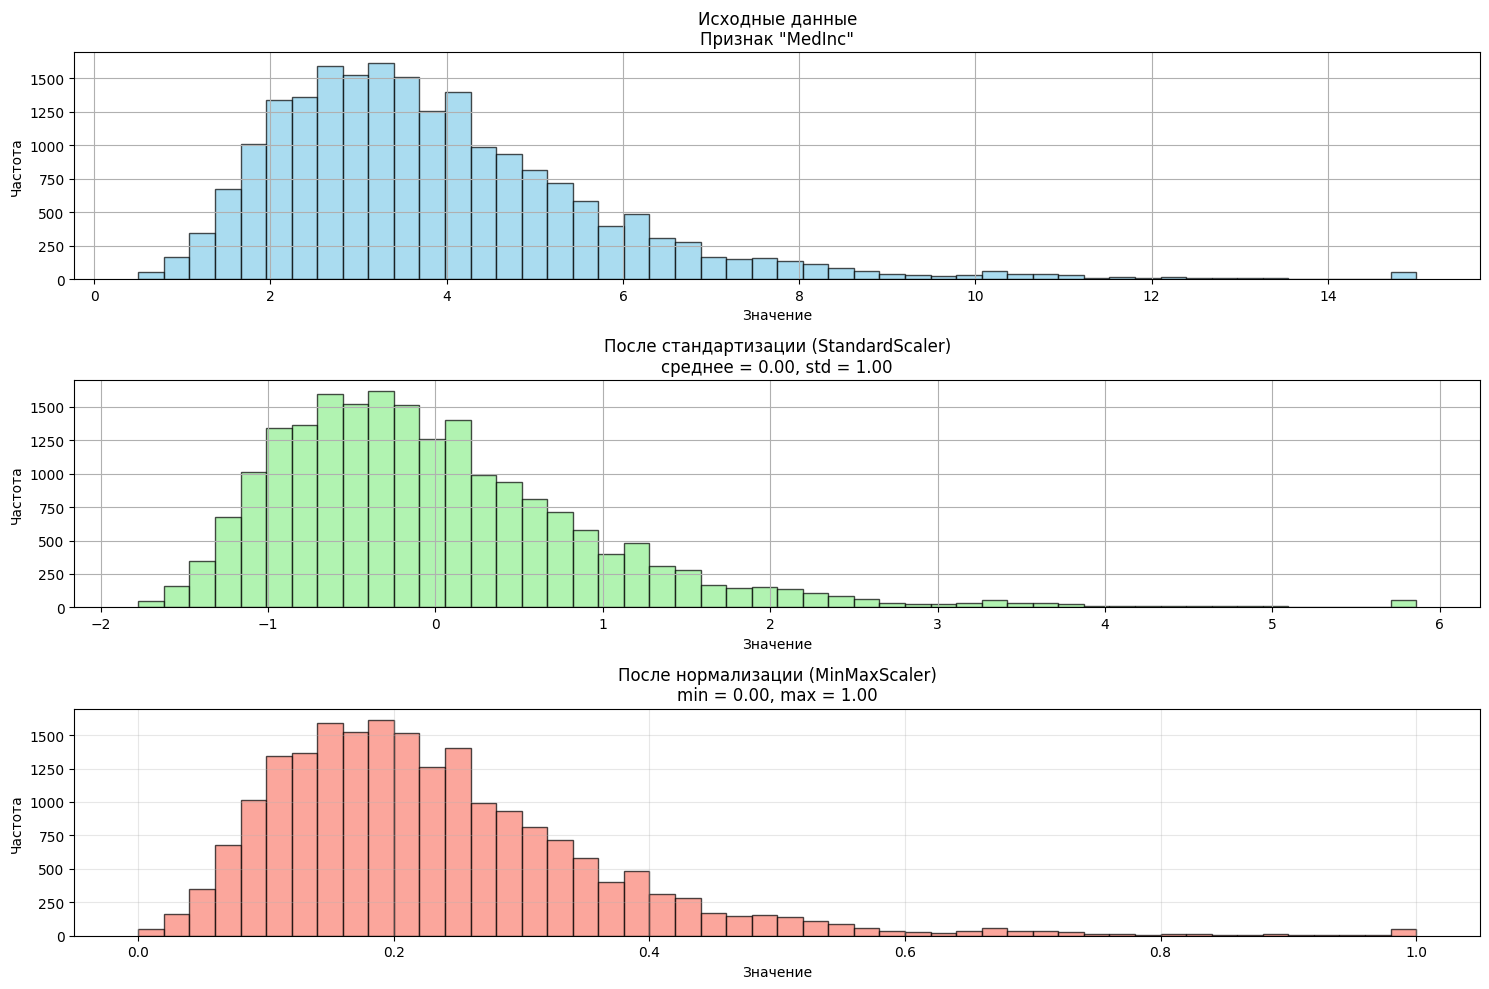


 СРАВНЕНИЕ ШКАЛ 

Статистика для признака 'MedInc':
Показатель           Исходные        Стандартизация  Нормализация   
Минимум              0.4999          -1.7743         0.0000         
Максимум             15.0001         5.8583          1.0000         
Среднее              3.8707          0.0000          0.2325         
Станд. отклонение    1.8998          1.0000          0.1310         

 АНАЛИЗ РЕЗУЛЬТАТОВ 
1. Исходные данные:
   - Значения имеют произвольный масштаб и диапазон
   - Распределение имеет выраженную правостороннюю асимметрию

 2. Стандартизация (StandardScaler):
   - Данные центрированы относительно 0 (среднее = 0)
   - Единичное стандартное отклонение (std = 1)
   - Форма распределения сохраняется (не меняет форму гистограммы)
   - Диапазон значений не ограничен

 3. Нормализация (MinMaxScaler):
   - Данные сжаты в диапазон [0, 1]
   - Сохраняется форма распределения
   - Все значения находятся между 0 и 1
   - Чувствительна к выбросам (максимальное значение ста

In [19]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# 1. Загрузка данных
print(" ЗАГРУЗКА ДАННЫХ ")
data = fetch_california_housing(as_frame=True)

# 2. Преобразование в pandas.DataFrame
df = data.frame
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print("\n Первые 5 строк:")
print(df.head())

# Описание признаков
print("\nОписание признаков:")
print(data.DESCR[:500])

# 3. Масштабирование признаков
print("\n МАСШТАБИРОВАНИЕ ПРИЗНАКОВ ")

df_standard = df.copy()
df_normalized = df.copy()

features = df.columns.tolist()
print(f"Признаки для масштабирования: {features}")

# Стандартизация (StandardScaler)
scaler_std = StandardScaler()
df_standard[features] = scaler_std.fit_transform(df[features])
print("\n Стандартизация выполнена (среднее = 0, std = 1)")

# Нормализация в диапазон [0, 1] (MinMaxScaler)
scaler_mm = MinMaxScaler()
df_normalized[features] = scaler_mm.fit_transform(df[features])
print(" Нормализация выполнена (диапазон [0, 1])")

# 4. Построение гистограмм для признака MedInc
print("\n ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ПРИЗНАКА MedInc ")

selected_feature = 'MedInc'

plt.figure(figsize=(15, 10))

# Гистограмма исходных данных
plt.subplot(3, 1, 1)
plt.hist(df[selected_feature], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.title(f'Исходные данные\nПризнак "{selected_feature}"')
plt.xlabel('Значение')
plt.ylabel('Частота')
plt.grid(True)

# Гистограмма после стандартизации
plt.subplot(3, 1, 2)
plt.hist(df_standard[selected_feature], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
plt.title(f'После стандартизации (StandardScaler)\nсреднее = {df_standard[selected_feature].mean():.2f}, '
          f'std = {df_standard[selected_feature].std():.2f}')
plt.xlabel('Значение')
plt.ylabel('Частота')
plt.grid(True)

# Гистограмма после нормализации
plt.subplot(3, 1, 3)
plt.hist(df_normalized[selected_feature], bins=50, color='salmon', edgecolor='black', alpha=0.7)
plt.title(f'После нормализации (MinMaxScaler)\nmin = {df_normalized[selected_feature].min():.2f}, '
          f'max = {df_normalized[selected_feature].max():.2f}')
plt.xlabel('Значение')
plt.ylabel('Частота')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Сравнение поведения шкал
print("\n СРАВНЕНИЕ ШКАЛ ")
print("\nСтатистика для признака 'MedInc':")
print(f"{'Показатель':<20} {'Исходные':<15} {'Стандартизация':<15} {'Нормализация':<15}")
print(f"{'Минимум':<20} {df[selected_feature].min():<15.4f} "
      f"{df_standard[selected_feature].min():<15.4f} "
      f"{df_normalized[selected_feature].min():<15.4f}")
print(f"{'Максимум':<20} {df[selected_feature].max():<15.4f} "
      f"{df_standard[selected_feature].max():<15.4f} "
      f"{df_normalized[selected_feature].max():<15.4f}")
print(f"{'Среднее':<20} {df[selected_feature].mean():<15.4f} "
      f"{df_standard[selected_feature].mean():<15.4f} "
      f"{df_normalized[selected_feature].mean():<15.4f}")
print(f"{'Станд. отклонение':<20} {df[selected_feature].std():<15.4f} "
      f"{df_standard[selected_feature].std():<15.4f} "
      f"{df_normalized[selected_feature].std():<15.4f}")

# 5. Анализ результатов
print("\n АНАЛИЗ РЕЗУЛЬТАТОВ ")
print("1. Исходные данные:")
print("   - Значения имеют произвольный масштаб и диапазон")
print("   - Распределение имеет выраженную правостороннюю асимметрию")

print("\n 2. Стандартизация (StandardScaler):")
print("   - Данные центрированы относительно 0 (среднее = 0)")
print("   - Единичное стандартное отклонение (std = 1)")
print("   - Форма распределения сохраняется (не меняет форму гистограммы)")
print("   - Диапазон значений не ограничен")

print("\n 3. Нормализация (MinMaxScaler):")
print("   - Данные сжаты в диапазон [0, 1]")
print("   - Сохраняется форма распределения")
print("   - Все значения находятся между 0 и 1")
print("   - Чувствительна к выбросам (максимальное значение становится 1)")

# Задание 4. Кодирование категориальных признаков

**Датасет:** adult (перепись населения США, income dataset)  
**Источник:** `sklearn.datasets.fetch_openml("adult")`

## Инструкции:

1. Загрузите данные и отберите признаки:
   - категориальные – `education`, `marital-status`, `occupation`
   - целевой признак – `income`

2. Проведите **Label Encoding** для признака `education`, предполагая, что уровни образования упорядочены.

3. Примените **One-Hot Encoding** к признакам `marital-status` и `occupation`.

4. Проверьте итоговую размерность таблицы до и после кодирования.

5. Убедитесь, что в one-hot-кодировании не присутствует дамми-ловушка.

In [20]:
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# 1. Загрузка данных
print(" ЗАГРУЗКА ДАННЫХ ")
adult = fetch_openml("adult", version=2, as_frame=True)
df = adult.frame

print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print("\n Первые 5 строк:")
print(df.head())

# 2. Отбор признаков
print("\n ОТБОР ПРИЗНАКОВ ")
selected_features = ['education', 'marital-status', 'occupation']
target = 'class'  # income (class)

df_selected = df[selected_features + [target]].copy()

print(f"Выбранные категориальные признаки: {selected_features}")
print(f"Целевой признак: {target}")
print(f"Размер таблицы: {df_selected.shape}")

print("\n Уникальные значения в признаке 'education':")
print(df_selected['education'].unique()[:10])
print(f"Всего уровней образования: {df_selected['education'].nunique()}")

print("\n Уникальные значения в признаке 'marital-status':")
print(df_selected['marital-status'].unique())

print("\nУникальные значения в признаке 'occupation':")
print(df_selected['occupation'].unique()[:10])
print(f"Всего профессий: {df_selected['occupation'].nunique()}")

# 3. Label Encoding для признака education
print("\n LABEL ENCODING (education) ")
education_order = [
    'Preschool', '1st-4th', '5th-6th', '7th-8th', '9th',
    '10th', '11th', '12th', 'HS-grad', 'Some-college',
    'Assoc-voc', 'Assoc-acdm', 'Bachelors', 'Masters',
    'Prof-school', 'Doctorate'
]

education_mapping = {level: i for i, level in enumerate(education_order)}
df_selected['education_encoded'] = df_selected['education'].map(education_mapping)

print(f"Пример кодирования:")
for level in education_order[:5]:
    print(f"  '{level}' -> {education_mapping[level]}")
print(f"  ...")

print(f"\n Первые 10 значений после кодирования:")
print(df_selected[['education', 'education_encoded']].head(10))

# 4. One-Hot Encoding для marital-status и occupation
print("\n ONE-HOT ENCODING (marital-status, occupation) ")

dummies_marital = pd.get_dummies(
    df_selected['marital-status'], 
    prefix='marital',
    drop_first=True
)

dummies_occupation = pd.get_dummies(
    df_selected['occupation'],
    prefix='occ',
    drop_first=True
)

print(f"Создано бинарных столбцов для 'marital-status': {dummies_marital.shape[1]}")
print(f"Создано бинарных столбцов для 'occupation': {dummies_occupation.shape[1]}")

df_encoded = pd.concat([
    df_selected['education_encoded'],
    dummies_marital,
    dummies_occupation,
    df_selected[target]
], axis=1)

print("\n Первые 5 строк после кодирования:")
print(df_encoded.head())

# 4. Проверка итоговой размерности
print("\n ПРОВЕРКА РАЗМЕРНОСТИ ")

print(f"Размер таблицы ДО кодирования: {df_selected.shape[0]} строк х {df_selected.shape[1]} столбцов")
print(f"  - Категориальные признаки: {len(selected_features)}")
print(f"  - Целевой признак: 1")

print(f"\n Размер таблицы ПОСЛЕ кодирования: {df_encoded.shape[0]} строк х {df_encoded.shape[1]} столбцов")
print(f"  - Label Encoding (education): 1 столбец")
print(f"  - One-Hot Encoding (marital-status): {dummies_marital.shape[1]} столбцов")
print(f"  - One-Hot Encoding (occupation): {dummies_occupation.shape[1]} столбцов")
print(f"  - Целевой признак: 1 столбец")

# 5. Проверка на наличие дамми-ловушки
print("\n ПРОВЕРКА ДАММИ-ЛОВУШКИ ")

marital_cols = [col for col in df_encoded.columns if col.startswith('marital_')]
if len(marital_cols) > 0:
    zero_rows = (df_encoded[marital_cols].sum(axis=1) == 0).sum()
    print(f"Для 'marital-status':")
    print(f" - Создано столбцов: {len(marital_cols)}")
    print(f" - Категорий в оригинале: {df_selected['marital-status'].nunique()}")
    print(f" - Строк, где все столбцы = 0: {zero_rows}")
    if zero_rows > 0:
        print(f" Дамми-ловушки нет (один столбец удален)")
    else:
        print(f" Возможна дамми-ловушка (все столбцы сохранены)")

occ_cols = [col for col in df_encoded.columns if col.startswith('occ_')]
if len(occ_cols) > 0:
    zero_rows = (df_encoded[occ_cols].sum(axis=1) == 0).sum()
    print(f"\nДля 'occupation':")
    print(f"  - Создано столбцов: {len(occ_cols)}")
    print(f"  - Категорий в оригинале: {df_selected['occupation'].nunique()}")
    print(f"  - Строк, где все столбцы = 0: {zero_rows}")
    if zero_rows > 0:
        print(f" Дамми-ловушки нет (один столбец удален)")
    else:
        print(f" Возможна дамми-ловушка (все столбцы сохранены)")

print("\n ИТОГ ")
print(f"  Кодирование категориальных признаков выполнено!")
print(f"  Исходная таблица: {df_selected.shape[0]} х {df_selected.shape[1]}")
print(f"  Закодированная таблица: {df_encoded.shape[0]} х {df_encoded.shape[1]}")
print(f"  Дамми-ловушка предотвращена с помощью drop_first=True")

 ЗАГРУЗКА ДАННЫХ 
Размер датасета: 48842 строк, 15 столбцов

 Первые 5 строк:
   age  workclass  fnlwgt     education  education-num      marital-status  \
0   25    Private  226802          11th              7       Never-married   
1   38    Private   89814       HS-grad              9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm             12  Married-civ-spouse   
3   44    Private  160323  Some-college             10  Married-civ-spouse   
4   18        NaN  103497  Some-college             10       Never-married   

          occupation relationship   race     sex  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                NaN    Own-child  White  Female     

# Задание 5. Комплексный EDA

**Датасет:** heart disease (заболевания сердца)  
**Источник:** `https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction`

## Инструкции:

Выполните полный цикл EDA:

1. Обзор структуры данных (`.info()`, `.describe()`).

2. Обнаружение и обработка пропущенных значений.

3. Обнаружение и удаление выбросов по признакам:
   - `age`
   - `cholesterol`
   - `restingbp`
   - `maxhr`

4. Масштабирование числовых признаков.

5. Кодирование категориальных признаков:
   - `sex`
   - `chestpain`
   - `exerciseangina`
   - `restecg`

6. Подготовьте отчет в виде Jupyter-ноутбука с комментариями к каждому этапу и промежуточными результатами.

In [29]:
from ucimlrepo import fetch_ucirepo

# 1. ЗАГРУЗКА ДАННЫХ
print("\n 1. ЗАГРУЗКА ДАННЫХ")

# Загружаем датасет Heart Disease (ID = 45)
heart_disease = fetch_ucirepo(id=45)
# Данные в виде pandas DataFrame
df = heart_disease.data.original

print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print("\n Первые 5 строк:")
print(df.head())

# Переименовываем столбцы для удобства (в соответствии с описанием)
column_names = {
    'age': 'Age',
    'sex': 'Sex',
    'cp': 'ChestPainType',
    'trestbps': 'RestingBP',
    'chol': 'Cholesterol',
    'fbs': 'FastingBS',
    'restecg': 'RestingECG',
    'thalach': 'MaxHR',
    'exang': 'ExerciseAngina',
    'oldpeak': 'Oldpeak',
    'slope': 'ST_Slope',
    'ca': 'NumVessels',
    'thal': 'Thalassemia',
    'num': 'HeartDisease'
}

rename_dict = {old: new for old, new in column_names.items() if old in df.columns}
df = df.rename(columns=rename_dict)

print("\n Переименованные столбцы:")
print(df.columns.tolist())

print("ЭТАП 1. ОБЗОР СТРУКТУРЫ ДАННЫХ")

print("\n 1.1. Информация о DataFrame (info()):")
print(df.info())

print("\n 1.2. Статистическое описание числовых признаков (describe()):")
print(df.describe())

# Находим категориальные признаки (с небольшим количеством уникальных значений)
print("\n1.3. Категориальные признаки в датасете (закодированы числами):")
for col in df.columns:
    if df[col].dtype in ['int64', 'float64'] and col != 'HeartDisease':
        unique_count = df[col].nunique()
        if unique_count <= 10:
            print(f"  {col}: {unique_count} уникальных значений, пример: {df[col].unique()[:5]}")

print("ЭТАП 2. ОБНАРУЖЕНИЕ И ОБРАБОТКА ПРОПУЩЕННЫХ ЗНАЧЕНИЙ")

missing_values = df.isna().sum()
print("\n Количество пропусков в каждом столбце:")
print(missing_values[missing_values > 0] if (missing_values > 0).any() else "Пропусков нет!")

if missing_values.sum() > 0:
    print("\n Обнаружены пропуски. Выполняем обработку...")
    for col in df.columns:
        if df[col].isna().sum() > 0:
            if df[col].dtype in ['int64', 'float64']:
                df[col].fillna(df[col].median(), inplace=True)
                print(f"  {col}: заполнено медианой ({df[col].median():.2f})")
            else:
                df[col].fillna(df[col].mode()[0], inplace=True)
                print(f"  {col}: заполнено модой ({df[col].mode()[0]})")
else:
    print("\n Пропущенные значения отсутствуют!")

print("ЭТАП 3. ОБНАРУЖЕНИЕ И УДАЛЕНИЕ ВЫБРОСОВ")

outlier_features = ['Age', 'Cholesterol', 'RestingBP', 'MaxHR']
actual_features = [f for f in outlier_features if f in df.columns]

print(f"\n Анализируемые признаки: {actual_features}")

def find_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

df_original = df.copy()
df_clean = df.copy()

print("\n Удаление выбросов методом IQR:")
for feature in actual_features:
    outliers, lower, upper = find_outliers_iqr(df_clean, feature)
    print(f"\n  Признак '{feature}':")
    print(f"    Q1 = {df_clean[feature].quantile(0.25):.2f}, Q3 = {df_clean[feature].quantile(0.75):.2f}")
    print(f"    Нижняя граница: {lower:.2f}, Верхняя граница: {upper:.2f}")
    print(f"    Количество выбросов ДО удаления: {len(outliers)}")
    
    df_clean = df_clean[(df_clean[feature] >= lower) & (df_clean[feature] <= upper)]

print(f"\n Результат удаления выбросов:")
print(f"  Исходное количество строк: {len(df_original)}")
print(f"  После удаления выбросов: {len(df_clean)}")
print(f"  Удалено строк: {len(df_original) - len(df_clean)}")
print(f"  Удалено процентов: {(len(df_original) - len(df_clean)) / len(df_original) * 100:.2f}%")

df = df_clean.copy()

print("ЭТАП 4. МАСШТАБИРОВАНИЕ ЧИСЛОВЫХ ПРИЗНАКОВ")

# Определяем числовые признаки (не категориальные)
numeric_features = []
for col in df.select_dtypes(include=[np.number]).columns:
    if col != 'HeartDisease' and df[col].nunique() > 10:
        numeric_features.append(col)

print(f"\n Числовые признаки для масштабирования: {numeric_features}")

df_standard = df.copy()
df_normalized = df.copy()

if len(numeric_features) > 0:
    scaler_std = StandardScaler()
    df_standard[numeric_features] = scaler_std.fit_transform(df[numeric_features])

    scaler_mm = MinMaxScaler()
    df_normalized[numeric_features] = scaler_mm.fit_transform(df[numeric_features])

    print("\n Стандартизация выполнена (среднее = 0, std = 1)")
    print(" Нормализация выполнена (диапазон [0, 1])")

    if 'Age' in numeric_features:
        print(f"\nПример масштабирования для признака 'Age':")
        print(f"  Исходные: min={df['Age'].min():.2f}, max={df['Age'].max():.2f}, mean={df['Age'].mean():.2f}")
        print(f"  Стандартизация: min={df_standard['Age'].min():.2f}, max={df_standard['Age'].max():.2f}, mean={df_standard['Age'].mean():.2f}")
        print(f"  Нормализация: min={df_normalized['Age'].min():.2f}, max={df_normalized['Age'].max():.2f}, mean={df_normalized['Age'].mean():.2f}")
else:
    print("\n Нет числовых признаков для масштабирования")

print("ЭТАП 5. КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")

print("\nРасшифровка категориальных признаков (UCI Heart Disease):")
print("""
  Sex (пол): 1 = Male, 0 = Female
  ChestPainType (cp): 1 = typical angina, 2 = atypical angina, 3 = non-anginal pain, 4 = asymptomatic
  RestingECG (restecg): 0 = normal, 1 = ST-T wave abnormality, 2 = left ventricular hypertrophy
  ExerciseAngina (exang): 1 = yes, 0 = no
  ST_Slope (slope): 1 = upsloping, 2 = flat, 3 = downsloping
  NumVessels (ca): number of major vessels (0-3)
  Thalassemia (thal): 3 = normal, 6 = fixed defect, 7 = reversible defect
  HeartDisease (num): 0 = no disease, 1-4 = disease
""")

# Категориальные признаки уже закодированы числами
cat_features = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'NumVessels', 'Thalassemia']
actual_cat_features = [f for f in cat_features if f in df.columns]

print(f"\n Категориальные признаки в датасете (уже в числовом формате): {actual_cat_features}")

# Так как признаки уже в числовом формате, one-hot-кодирование не требуется
df_encoded = df.copy()

print("\n One-Hot Encoding не требуется (категориальные признаки уже закодированы числами)")
print(f"\n Размер таблицы: {df.shape}")

print("ИТОГОВЫЙ ОТЧЕТ ПО EDA")

print("\n 1. СТРУКТУРА ДАННЫХ:")
print(f"   - Исходный размер: {df_original.shape[0]} строк, {df_original.shape[1]} столбцов")
print(f"   - После удаления выбросов: {df.shape[0]} строк")
print(f"   - После кодирования: {df_encoded.shape[1]} столбцов (кодирование не потребовалось)")

print("\n 2. ОБРАБОТКА ПРОПУСКОВ:")
if missing_values.sum() == 0:
    print("   - Пропущенные значения: отсутствуют")
else:
    print(f"   - Пропущенные значения: обработаны ({missing_values.sum()} значений)")

print("\n 3. УДАЛЕНИЕ ВЫБРОСОВ:")
print(f"   - Удалено строк: {len(df_original) - len(df)}")
print(f"   - Удалено процентов: {(len(df_original) - len(df)) / len(df_original) * 100:.2f}%")

print("\n 4. МАСШТАБИРОВАНИЕ:")
print(f"   - Числовых признаков: {len(numeric_features)}")
print("   - Методы: StandardScaler, MinMaxScaler")

print("\n 5. КОДИРОВАНИЕ:")
print(f"   - Категориальных признаков: {len(actual_cat_features)}")
print("   - Категориальные признаки уже в числовом формате (закодированы от 0/1)")
print("   - One-Hot Encoding: не требуется")


 1. ЗАГРУЗКА ДАННЫХ
Размер датасета: 303 строк, 14 столбцов

 Первые 5 строк:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  num  
0  0.0   6.0    0  
1  3.0   3.0    2  
2  2.0   7.0    1  
3  0.0   3.0    0  
4  0.0   3.0    0  

 Переименованные столбцы:
['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'NumVessels', 'Thalassemia', 'HeartDisease']
ЭТАП 1. ОБЗОР СТРУКТУРЫ ДАННЫХ

 1.1. Информация о DataFrame (info()):
<class 'pandas.DataFrame'>
RangeIn

C:\Users\User\AppData\Local\Temp\ipykernel_24320\1888645012.py:66: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].median(), inplace=True)
C:\Users\User\AppData\Local\Temp\ipykernel_24320\1888645012.py:66: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment u

# Индивидуальное практическое задание (вариант 7)

## Цель
Выполнить полноценный исследовательский анализ данных (EDA), применяя методы выявления и обработки пропусков, выбросов, масштабирования числовых признаков и кодирования категориальных переменных.

## Датасет
- **Название:** `mpg` (Fuel Economy – расход топлива автомобилей)
- **Источник:** `seaborn.load_dataset("mpg")`
- **Описание:** данные об автомобилях 1970-1982 годов, содержащие информацию о расходе топлива, мощности, весе, ускорении и стране происхождения

## Условия к выполнению

1. Выберите реальный табличный датасет со структурой не менее 8 признаков и целевым признаком, подходящим для задач регрессии или классификации.

2. Убедитесь, что в датасете присутствуют:
   - числовые признаки
   - категориальные признаки
   - целевой столбец (предсказуемый признак)
   - (необязательно) пропущенные значения или выбросы

## Требования к выполнению

Выполните последовательные шаги исследовательского анализа:

1. **Обзор структуры данных:** загрузите датасет, выведите общую информацию (`.info()`, `.describe()`), опишите сколько признаков, каких типов, какова структура целевого признака.

2. **Обнаружение и обработка пропусков:** определите, есть ли пропущенные значения, обоснуйте выбранный способ их устранения (удаление, заполнение средним/модой и т.д.), примените выбранный способ.

3. **Обнаружение и удаление выбросов:** выберите 3-5 числовых признаков, используя метод IQR, удалите выбросы, сравните объём данных до и после очистки.

4. **Масштабирование числовых признаков:** выполните стандартизацию (z-преобразование) с помощью `StandardScaler`, объясните, зачем выполняется масштабирование.

5. **Кодирование категориальных признаков:** выполните Label Encoding для порядковых признаков (при наличии), One-Hot Encoding для номинальных признаков, проверьте, исключена ли дамми-ловушка.

6. **Финальный набор данных:** убедитесь, что датасет не содержит пропусков, выбросов, категориальных данных в строковом виде, признаки приведены к числовому виду, масштабированы, представьте итоговый DataFrame, готовый к использованию в моделях.

In [31]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# 1. ЗАГРУЗКА ДАННЫХ И ОБЗОР СТРУКТУРЫ
print("\n 1. ЗАГРУЗКА ДАННЫХ И ОБЗОР СТРУКТУРЫ")

df = sns.load_dataset("mpg")
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print("\n Первые 5 строк:")
print(df.head())
print("\n Информация о DataFrame:")
print(df.info())
print("\n Статистическое описание:")
print(df.describe())

print("2. ОБРАБОТКА ПРОПУСКОВ")

print("Пропуски до обработки:")
print(df.isna().sum())
df = df.drop(columns=['name'])
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())
print(f"\n Пропуски после обработки: {df.isna().sum().sum()}")

print("3. УДАЛЕНИЕ ВЫБРОСОВ (IQR)")

outlier_features = ['horsepower', 'displacement', 'weight', 'acceleration']
df_original = df.copy()
df_clean = df.copy()

for feature in outlier_features:
    Q1 = df_clean[feature].quantile(0.25)
    Q3 = df_clean[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean = df_clean[(df_clean[feature] >= lower) & (df_clean[feature] <= upper)]
    print(f"{feature}: удалено {len(df_original) - len(df_clean)} выбросов")

print(f"\n Исходный размер: {len(df_original)}, После удаления: {len(df_clean)}")
df = df_clean.copy()

print("4. МАСШТАБИРОВАНИЕ ЧИСЛОВЫХ ПРИЗНАКОВ")

numeric_features = ['displacement', 'horsepower', 'weight', 'acceleration']
scaler_std = StandardScaler()
df_standard = df.copy()
df_standard[numeric_features] = scaler_std.fit_transform(df[numeric_features])
print("Стандартизация выполнена")

print("5. КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")

df['cylinders'] = df['cylinders'].astype('category').cat.codes
df['model_year'] = df['model_year'].astype('category').cat.codes
origin_dummies = pd.get_dummies(df['origin'], prefix='origin', drop_first=True)
df = pd.concat([df, origin_dummies], axis=1)
df = df.drop(columns=['origin'])
print("Категориальные признаки закодированы")

print("6. ФИНАЛЬНЫЙ ДАТАСЕТ")

print(f"Размер: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"Пропуски: {df.isna().sum().sum()}")
print("\n Первые 5 строк:")
print(df.head())


 1. ЗАГРУЗКА ДАННЫХ И ОБЗОР СТРУКТУРЫ
Размер датасета: 398 строк, 9 столбцов

 Первые 5 строк:
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  

 Информация о DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --